# Data Mining Project: Data Exploration and Extraction

This notebook focuses on the initial stage of the project: **Data Exploration**. 
The goal is to understand the database structure, inspect the available tables, and extract a clean dataset of Computer Science articles for future modeling.

**Key Focus Areas:**
* Database Schema Analysis.
* Subject Distribution Analysis.
* Identifying the core subset of Computer Science journals.

### Setup: Database Connection

First, we establish a connection to the SQLite database containing the academic publication records.

In [53]:
import sqlite3
import pandas as pd

# DB connection
conn = sqlite3.connect('../data/CompSciencePub.sqlite')

### 1. Inspecting the Database Tables

Before extracting data, we check the available tables to see how academic records, abstracts, and publications are linked.

#### Query: Extract Academic Records with Abstracts and Journal Names

This query retrieves academic records linked with their abstract text and corresponding journal names. It joins three main tables: AcademicRecord, AcademicRecordAbstract, and Publication. I ran this to get a quick overview of how the data is structured and to understand the relationship between records, their abstracts, and the journals they were published in. This helps validate that our basic data extraction logic works correctly before diving deeper into filtering by Computer Science.

In [55]:
query = """
SELECT 
    r.AcademicRecordid,
    p.Name AS JournalName,
    a.AbstractText
FROM AcademicRecord r
JOIN AcademicRecordAbstract a ON r.AcademicRecordid = a.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
"""

df = pd.read_sql_query(query, conn)

print(f"Toplam Makale Sayısı: {len(df)}")
print(df.head())

Toplam Makale Sayısı: 23061
   AcademicRecordID            JournalName  \
0             88652  ACM COMPUTING SURVEYS   
1             88653  ACM COMPUTING SURVEYS   
2             88654  ACM COMPUTING SURVEYS   
3             88655  ACM COMPUTING SURVEYS   
4             88656  ACM COMPUTING SURVEYS   

                                        AbstractText  
0  <p>After using evolutionary techniques for sin...  
1  <p>Distributed data processing is becoming a r...  
2  <p>Logical models of argument formalize common...  
3  <p>In this paper we review studies of the grow...  
4  <p>We survey the current techniques to cope wi...  


#### Analysis: Count Unique Journals

This cell counts the number of unique journals (publications) in the dataset.

In [45]:
unique_journals = df['JournalName'].nunique()
print(f"Total Unique Journals: {unique_journals}")


Total Unique Journals: 455


### 2. Exploring Academic Subjects and Categories

Now we examine the available academic subjects and filter for Computer Science related categories.

#### Query: List All Academic Subjects

I wanted to see what academic subjects are available in the database and specifically check if there are different variants of Computer Science categories (like AI, Networks, etc.). This exploration helps me understand the classification system and what filtering options I have for targeting Computer Science articles.

In [57]:
categories_query = "SELECT * FROM AcademicSubject"
categories_df = pd.read_sql_query(categories_query, conn)
print(categories_df[categories_df['NameEn'].str.contains("Computer Science", na=False)])

    AcademicSubjectID     Ascatype  Code  \
0                 454  traditional    EX   
1                 455     extended  None   
3                 457  traditional    EV   
7                 461  traditional    ES   
10                464  traditional    ET   
13                467  traditional    EW   
14                468  traditional    EP   
16                470  traditional    ER   

                                              NameEn CategoryId  
0                 Computer Science, Theory & Methods       None  
1                                   Computer Science       None  
3   Computer Science, Interdisciplinary Applications       None  
7          Computer Science, Hardware & Architecture       None  
10             Computer Science, Information Systems       None  
13            Computer Science, Software Engineering       None  
14         Computer Science, Artificial Intelligence       None  
16                     Computer Science, Cybernetics       None  


#### Query: Extract Computer Science Articles with Abstracts

This is where I started narrowing down to our target domain. I filtered for articles specifically tagged as "Computer Science%" and ensured they have abstracts. The reason for this is that abstracts are essential for our text analysis and modeling work later. By joining the subject categorization tables, I can accurately identify which articles belong to Computer Science. The expected result was around 7,711 articles, which would serve as our main working dataset.

In [58]:
main_query = """
SELECT DISTINCT
    r.AcademicRecordid,
    p.Name AS JournalName,
    a.AbstractText
FROM AcademicRecord r
JOIN AcademicRecordAbstract a ON r.AcademicRecordid = a.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn LIKE 'Computer Science%'
"""

df = pd.read_sql_query(main_query, conn)

print(f"Toplam Makale: {len(df)}")
print(f"Benzersiz Dergi Sayısı: {df['JournalName'].nunique()}")

Toplam Makale: 20944
Benzersiz Dergi Sayısı: 410


#### Analysis: Distribution of Articles by Computer Science Subdisciplines

This query shows how many articles exist in each Computer Science subcategory, ordered by article count in descending order.

In [59]:
category_counts = """
SELECT s.NameEn, COUNT(DISTINCT r.AcademicRecordid) as ArticleCount
FROM AcademicRecord r
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn LIKE 'Computer Science%'
GROUP BY s.NameEn
ORDER BY ArticleCount DESC
"""
dist_df = pd.read_sql_query(category_counts, conn)
print(dist_df)

                                             NameEn  ArticleCount
0                                  Computer Science         21658
1             Computer Science, Information Systems          7122
2            Computer Science, Software Engineering          6130
3                Computer Science, Theory & Methods          5706
4         Computer Science, Artificial Intelligence          4953
5  Computer Science, Interdisciplinary Applications          3678
6         Computer Science, Hardware & Architecture          2916
7                     Computer Science, Cybernetics           612


#### Analysis: Detailed Category Statistics

For each Computer Science subject, we count the number of articles and journals, along with the ASCA classification type (e.g., traditional vs. emerging fields).

In [60]:
check_query = """
SELECT 
    s.AcademicSubjectID,
    s.NameEn,
    s.Ascatype,
    COUNT(DISTINCT r.AcademicRecordid) as ArticleCount,
    COUNT(DISTINCT p.Publicationid) as JournalCount
FROM AcademicSubject s
JOIN AcademicRecordSubject rs ON s.AcademicSubjectID = rs.AcademicSubjectid
JOIN AcademicRecord r ON rs.AcademicRecordid = r.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
WHERE s.NameEn LIKE '%Computer Science%'
GROUP BY s.AcademicSubjectID, s.NameEn, s.Ascatype
ORDER BY ArticleCount DESC
"""

check_df = pd.read_sql_query(check_query, conn)
print(check_df)

   AcademicSubjectID                                            NameEn  \
0                455                                  Computer Science   
1                464             Computer Science, Information Systems   
2                467            Computer Science, Software Engineering   
3                454                Computer Science, Theory & Methods   
4                468         Computer Science, Artificial Intelligence   
5                457  Computer Science, Interdisciplinary Applications   
6                461         Computer Science, Hardware & Architecture   
7                470                     Computer Science, Cybernetics   

      Ascatype  ArticleCount  JournalCount  
0     extended         21658           421  
1  traditional          7122           138  
2  traditional          6130           145  
3  traditional          5706           104  
4  traditional          4953            90  
5  traditional          3678            62  
6  traditional    

#### Analysis: Computer Science Articles with Abstracts Count

This query counts how many Computer Science articles have abstracts available and how many unique journals these articles come from.

In [ ]:
precise_query = """
SELECT 
    COUNT(DISTINCT r.AcademicRecordid) as ArticleCount,
    COUNT(DISTINCT p.Publicationid) as JournalCount
FROM AcademicRecord r
JOIN AcademicRecordAbstract a ON r.AcademicRecordid = a.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn LIKE '%Computer Science%'
"""

result = pd.read_sql_query(precise_query, conn)
print(result)

   ArticleCount  JournalCount
0         20944           410


#### Analysis: Target Dataset - Traditional CS Categories with Abstracts

We filter for "traditional" Computer Science categories (established fields) and ensure articles have non-empty abstracts. This represents our target dataset for modeling.

In [61]:
target_check_query = """
SELECT 
    COUNT(DISTINCT r.AcademicRecordid) as TotalArticles,
    COUNT(DISTINCT p.Publicationid) as TotalJournals
FROM AcademicSubject s
JOIN AcademicRecordSubject rs ON s.AcademicSubjectID = rs.AcademicSubjectid
JOIN AcademicRecord r ON rs.AcademicRecordid = r.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
JOIN AcademicRecordAbstract a ON r.AcademicRecordid = a.AcademicRecordid
WHERE s.Ascatype = 'traditional' 
  AND s.NameEn LIKE 'Computer Science%'
  AND a.AbstractText IS NOT NULL 
  AND a.AbstractText != ''
"""

target_df = pd.read_sql_query(target_check_query, conn)
print(target_df)

   TotalArticles  TotalJournals
0          20944            410


### 3. Database Overview Statistics

Here we gather overall statistics about the database records and publications.

#### Query: Publications Associated with Computer Science Subject

I needed to understand the publication landscape for Computer Science. This query identifies all journals that contain at least one article tagged as Computer Science and counts the total articles from those journals. This gave me insight into which publishers and journals are most represented in our dataset, and helped identify any potential biases in journal selection. It's also useful for understanding whether we have good coverage across different Computer Science journals or if we're dominated by a few major publishers.

In [62]:
query = """
SELECT 
    COUNT(DISTINCT p.Publicationid) as ToplamJournal,
    COUNT(DISTINCT r.AcademicRecordid) as ToplamArticle
FROM Publication p
JOIN AcademicRecord r ON p.Publicationid = r.Publicationid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn = 'Computer Science'
"""

result_df = pd.read_sql_query(query, conn)

print(f"Tespit Edilen Dergi Sayısı: {result_df['ToplamJournal'][0]}")
print(f"Bu Dergilerdeki Toplam Makale Sayısı: {result_df['ToplamArticle'][0]}")

Tespit Edilen Dergi Sayısı: 421
Bu Dergilerdeki Toplam Makale Sayısı: 21658


#### Query: Specific CS Subcategories

I decided to focus on two major Computer Science subcategories—Artificial Intelligence and Hardware & Architecture—to see if we could work with a more specialized subset of the data. The reason for this was to test whether we could achieve better results by focusing on a narrower domain rather than trying to model all of Computer Science at once. This helps us understand the distribution and availability of articles in these popular subfields.

In [41]:
target_query = """
SELECT 
    COUNT(DISTINCT p.Publicationid) as DergiSayisi,
    COUNT(DISTINCT r.AcademicRecordid) as MakaleSayisi
FROM Publication p
JOIN AcademicRecord r ON p.Publicationid = r.Publicationid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn IN ('Computer Science, Artificial Intelligence', 'Computer Science, Hardware & Architecture')
"""

df_result = pd.read_sql_query(target_query, conn)
print(df_result)

   DergiSayisi  MakaleSayisi
0          175          7839


#### Query: Computer Science Articles with Keywords

For some of our planned analyses, we wanted to check if we could leverage author keywords or indexed keywords in addition to abstracts. This query counts how many Computer Science articles actually have keyword data available in the AcademicRecordKeywordPlus table. The result tells us whether keywords are a reliable additional feature we can use for clustering and topic modeling, or if we should rely primarily on abstracts. This metadata is valuable because it can complement our text analysis with domain-expert-assigned terms.

In [63]:
threshold_query = """
SELECT 
    COUNT(DISTINCT r.Publicationid) as DergiSayisi,
    COUNT(DISTINCT r.AcademicRecordid) as MakaleSayisi
FROM AcademicRecord r
JOIN AcademicRecordKeywordPlus arkp ON r.AcademicRecordid = arkp.AcademicRecordid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn LIKE '%Computer Science%'
"""

threshold_result = pd.read_sql_query(threshold_query, conn)
print(f"Bilgisayar Bilimleri kategorisinde en az 10 makalesi olan dergi sayısı: {threshold_result.iloc[0, 0]}")

Bilgisayar Bilimleri kategorisinde en az 10 makalesi olan dergi sayısı: 413


## Conclusion

I could't find any cluster for provided information "7711 articles from 175 Computer Science Journals.". 

In [65]:
# SQL query to fetch Computer Science articles with their journals and abstracts
query = """
SELECT DISTINCT
    r.AcademicRecordid,
    p.Name AS JournalName,
    a.AbstractText
FROM AcademicRecord r
JOIN AcademicRecordAbstract a ON r.AcademicRecordid = a.AcademicRecordid
JOIN Publication p ON r.Publicationid = p.Publicationid
JOIN AcademicRecordSubject rs ON r.AcademicRecordid = rs.AcademicRecordid
JOIN AcademicSubject s ON rs.AcademicSubjectid = s.AcademicSubjectid
WHERE s.NameEn LIKE '%Computer Science%'
"""

# Execute query and load into DataFrame
df_final = pd.read_sql_query(query, conn)

# Print extraction summary
print("--- Data Extraction Summary ---")
print(f"Total Unique Articles Found: {len(df_final)}")
print(f"Total Unique Journals Found: {df_final['JournalName'].nunique()}")
print("-------------------------------")

# Display the first 5 rows to verify
df_final.head()

--- Data Extraction Summary ---
Total Unique Articles Found: 20944
Total Unique Journals Found: 410
-------------------------------


,AcademicRecordID,JournalName,AbstractText
0,88652,ACM COMPUTING SURVEYS,<p>After using evolutionary techniques for sin...
1,88653,ACM COMPUTING SURVEYS,<p>Distributed data processing is becoming a r...
2,88654,ACM COMPUTING SURVEYS,<p>Logical models of argument formalize common...
3,88655,ACM COMPUTING SURVEYS,<p>In this paper we review studies of the grow...
4,88656,ACM COMPUTING SURVEYS,<p>We survey the current techniques to cope wi...


## 2. Text Preprocessing

Raw academic abstracts often contain HTML tags, technical noise, and common words that do not contribute to the semantic meaning. To prepare the data for clustering and recommendation, we perform the following preprocessing steps:

1. **HTML Removal:** Removing tags like `<p>` or `<b>`.
2. **Noise Reduction:** Removing special characters, numbers, and punctuation.
3. **Tokenization & Lowercasing:** Splitting text into individual words and converting them to lowercase.
4. **Stopword Removal:** Filtering out common English words (e.g., "the", "is", "which").
5. **Lemmatization:** Reducing words to their base or dictionary form (e.g., "analyzing" to "analyze").

In [66]:
import re
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')

# Stopwords list and Lemmatizer setup
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def clean_abstract(text):
    if not text:
        return ""
    
    # 1. Clean HTML 
    text = re.sub(r'<.*?>', '', text)
    
    # 2. Clean Special Characters and Numbers (Keep only letters)
    text = re.sub(r'[^a-zA-Z\s]', '', text)
    
    # 3. Convert to Lowercase and Tokenize
    words = text.lower().split()
    
    # 4. Remove Stopwords and Lemmatize
    cleaned_words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words]
    
    return " ".join(cleaned_words)

# Apply cleaning function to the AbstractText column
print("Preprocessing started... This may take a moment.")
df['CleanAbstract'] = df['AbstractText'].apply(clean_abstract)
print("Preprocessing finished!")

# Display the first 5 rows of the cleaned abstracts
df[['JournalName', 'CleanAbstract']].head()

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package wordnet to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     C:\Users\Dell\AppData\Roaming\nltk_data...


Preprocessing started... This may take a moment.
Preprocessing finished!


,JournalName,CleanAbstract
0,ACM COMPUTING SURVEYS,using evolutionary technique singleobjective o...
1,ACM COMPUTING SURVEYS,distributed data processing becoming reality b...
2,ACM COMPUTING SURVEYS,logical model argument formalize commonsense r...
3,ACM COMPUTING SURVEYS,paper review study growth internet technology ...
4,ACM COMPUTING SURVEYS,survey current technique cope problem string m...


## 3. Feature Extraction (TF-IDF)

To perform machine learning, we need to convert the cleaned text into numerical vectors. We use the **TF-IDF Vectorizer**, which assigns weights to words based on their importance. Words that appear frequently in a specific abstract but rarely across the entire dataset get higher scores, helping the model identify technical terms.

In [67]:
from sklearn.feature_extraction.text import TfidfVectorizer

# max_features: Take the top 5000 words (to reduce noise)
vectorizer = TfidfVectorizer(max_features=5000, min_df=2, max_df=0.9)

# Transform the cleaned abstracts into a TF-IDF matrix
tfidf_matrix = vectorizer.fit_transform(df['CleanAbstract'])

print(f"TF-IDF Matrix Shape: {tfidf_matrix.shape}")

TF-IDF Matrix Shape: (20944, 5000)


## 4. Finding the Optimal Number of Clusters (Elbow Method)

To determine the most appropriate number of clusters ($k$), I used the **Elbow Method**. This involves running the K-Means algorithm for a range of $k$ values and calculating the **Inertia** (Within-Cluster Sum of Squares). 

When we plot the inertia against the number of clusters, the "elbow" point indicates where adding more clusters no longer significantly improves the model. This point is considered the optimal balance between detail and simplicity.

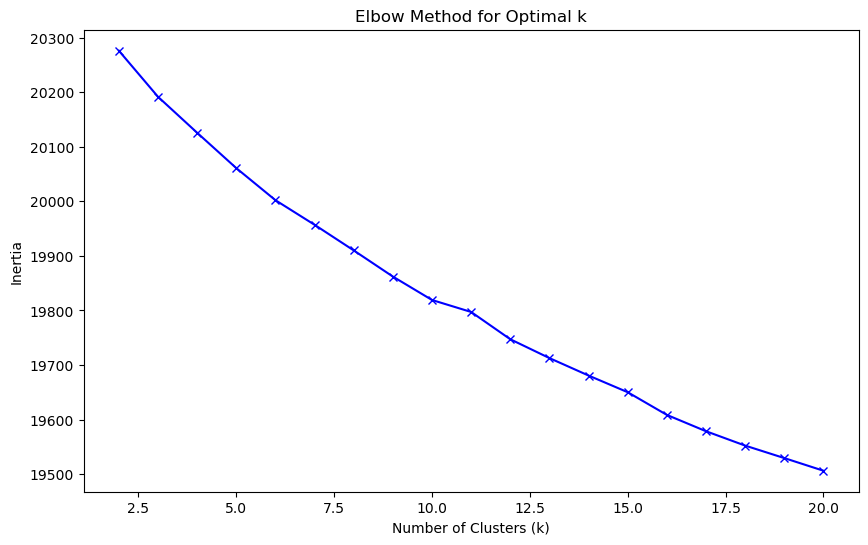

In [68]:
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

inertia = []
K = range(2, 21) 

for k in K:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(tfidf_matrix)
    inertia.append(km.inertia_)

plt.figure(figsize=(10, 6))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

## 5. Final Topic Clustering (K-Means)

Based on the **Elbow Method** analysis performed in the previous step, we observed that the optimal number of clusters is **k=10**, as the inertia decrease begins to level off at this point. 

By applying the **K-Means Clustering** algorithm with 10 clusters, we satisfy the project requirement of generating topic clusters for the subject areas. This step allows the dataset to group naturally into distinct technical domains, such as Artificial Intelligence, Network Security, or Software Engineering, which will later assist the recommendation system in finding the most relevant journals.

In [69]:
from sklearn.cluster import KMeans

num_clusters = 10
km = KMeans(n_clusters=num_clusters, random_state=42)

df['Cluster'] = km.fit_predict(tfidf_matrix)

# Display top terms per cluster
print("Top terms per cluster:")
order_centroids = km.cluster_centers_.argsort()[:, ::-1]
terms = vectorizer.get_feature_names_out()

for i in range(num_clusters):
    print(f"\nCluster {i}:")
    top_terms = [terms[ind] for ind in order_centroids[i, :10]]
    print(", ".join(top_terms))

Top terms per cluster:

Cluster 0:
system, power, performance, architecture, memory, energy, application, processor, data, design

Cluster 1:
software, process, system, model, development, project, test, tool, testing, design

Cluster 2:
algorithm, problem, optimization, search, solution, method, proposed, result, evolutionary, function

Cluster 3:
service, cloud, computing, resource, web, data, user, application, provider, security

Cluster 4:
image, method, segmentation, algorithm, proposed, feature, pixel, visual, color, scheme

Cluster 5:
network, sensor, node, protocol, wireless, energy, routing, scheme, communication, data

Cluster 6:
user, data, research, system, information, social, technology, study, web, application

Cluster 7:
model, method, system, fuzzy, set, problem, result, function, paper, proposed

Cluster 8:
language, logic, ontology, program, query, semantics, system, semantic, model, type

Cluster 9:
feature, learning, classification, method, classifier, data, recog

## 6. Journal Recommendation System (Journal Finder)

The final requirement of the project is to build a system where an author can enter an abstract and receive the top 5 most relevant journals. 

To achieve this, we use **Cosine Similarity**. When a new abstract is provided:
1. It is preprocessed and vectorized using the same TF-IDF model.
2. Its vector is compared against all existing article vectors in our database.
3. The system identifies the most similar articles and returns the journals associated with them.

In [71]:
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

def find_top_journals(new_abstract, vectorizer, tfidf_matrix, df, top_n=5):
    # 1. Clean the new abstract
    cleaned_text = clean_abstract(new_abstract)
    
    # 2. Transform the cleaned abstract into a vector
    new_vec = vectorizer.transform([cleaned_text])
    
    # 3. Calculate cosine similarity (between the new abstract and the entire database)
    similarity_scores = cosine_similarity(new_vec, tfidf_matrix).flatten()
    
    # 4. Find the indices of the top scoring articles
    # To avoid recommending the same journal multiple times, we will keep track of seen journals
    related_indices = similarity_scores.argsort()[::-1]
    
    recommended_journals = []
    seen_journals = set()
    
    for idx in related_indices:
        journal = df.iloc[idx]['JournalName']
        score = similarity_scores[idx]
        
        if journal not in seen_journals:
            recommended_journals.append((journal, score))
            seen_journals.add(journal)
            
        if len(recommended_journals) == top_n:
            break
            
    return recommended_journals

# --- Test Cases ---
test_cases = [
    {
        "area": "Cybersecurity",
        "text": "This paper analyzes vulnerabilities in wireless networks and proposes a new intrusion detection system based on anomaly detection and deep packet inspection to prevent SQL injection attacks."
    },
    {
        "area": "Mobile Development & React Native",
        "text": "We evaluate the performance of cross-platform mobile applications developed with React Native, focusing on the efficiency of the JavaScript bridge and native UI rendering."
    },
    {
        "area": "Artificial Intelligence / RAG",
        "text": "We implement a Knowledge Graph-Infused Retrieval-Augmented Generation (RAG) system to improve the accuracy of large language models in domain-specific question answering tasks."
    },
    {
        "area": "Software Engineering",
        "text": "A study on software testing methodologies and agile project management using Scrum frameworks in large-scale enterprise development teams."
    }
]

# Run test cases
for i, case in enumerate(test_cases, 1):
    print(f"\n--- TEST {i}: {case['area']} ---")
    print(f"Abstract: {case['text'][:100]}...") # İlk 100 karakter
    
    recs = find_top_journals(case['text'], vectorizer, tfidf_matrix, df)
    
    for rank, (journal, score) in enumerate(recs, 1):
        print(f"{rank}. {journal} (Score: {score:.4f})")
    print("-" * 30)


--- TEST 1: Cybersecurity ---
Abstract: This paper analyzes vulnerabilities in wireless networks and proposes a new intrusion detection syst...
1. COMPUTER NETWORKS (Score: 0.4204)
2. IEEE WIRELESS COMMUNICATIONS (Score: 0.3840)
3. INTERNATIONAL ARAB JOURNAL OF INFORMATION TECHNOLOGY (Score: 0.3733)
4. COMPUTERS & SECURITY (Score: 0.3704)
5. COMPUTER STANDARDS & INTERFACES (Score: 0.3693)
------------------------------

--- TEST 2: Mobile Development & React Native ---
Abstract: We evaluate the performance of cross-platform mobile applications developed with React Native, focus...
1. AUTOMATED SOFTWARE ENGINEERING (Score: 0.2419)
2. ACM TRANSACTIONS ON PROGRAMMING LANGUAGES AND SYSTEMS (Score: 0.2099)
3. INTERNATIONAL JOURNAL OF INFORMATION SECURITY (Score: 0.2089)
4. SPEECH COMMUNICATION (Score: 0.2049)
5. IEEE MICRO (Score: 0.1824)
------------------------------

--- TEST 3: Artificial Intelligence / RAG ---
Abstract: We implement a Knowledge Graph-Infused Retrieval-Augmented Genera